# Dviračių paklausos prognozė – SVR

**Tikslas:** prognozuoti kitos valandos bendrą nuomų skaičių (`cnt`) iš UCI `hour.csv`.

Vienodos eksperimento taisyklės visuose trijuose notebook: chronologinis rolling-origin DEV vertinimas, paskutinės 30 dienų TEST, tas pats baseline ir tos pačios MAE/RMSE/piko neįvertinimo metrikos. Galutinis TEST nenaudojamas hiperparametrams parinkti.

**Svarbi leakage taisyklė:** `casual` ir `registered` nenaudojami; būsimos valandos faktiniai orai taip pat nenaudojami.

In [1]:
import warnings, sys, platform, json, time
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
SEED = 42
np.random.seed(SEED)
DATA_PATH = Path("hour.csv") if Path("hour.csv").exists() else Path("../hour.csv") if Path("../hour.csv").exists() else Path("/mnt/data/hour.csv")
print("Python:", sys.version.split()[0], "| Platform:", platform.platform())
print("Duomenys:", DATA_PATH)

Python: 3.11.9 | Platform: Windows-10-10.0.26200-SP0
Duomenys: hour.csv


## 1. Duomenų paruošimo grandinė ir baseline

In [2]:
df = pd.read_csv(DATA_PATH)
df["datetime"] = pd.to_datetime(df["dteday"]) + pd.to_timedelta(df["hr"], unit="h")
df = df.sort_values("datetime").drop_duplicates("datetime").reset_index(drop=True)
print("Pradinė forma:", df.shape, "| Trūkstamos reikšmės:", int(df.isna().sum().sum()))

# casual ir registered NENAUDOJAMI: cnt = casual + registered, todėl tai būtų tiesioginis target leakage.
# Prognozuojame cnt kitai valandai. Tikslas prijungiamas pagal tikslų laiką, ne pagal eilutės numerį.
target_map = df.set_index("datetime")["cnt"]
df["target_time"] = df["datetime"] + pd.Timedelta(hours=1)
df["y"] = df["target_time"].map(target_map)

# Žinomi būsimos valandos kalendoriniai požymiai.
df["target_hr"] = df["target_time"].dt.hour
df["target_weekday"] = df["target_time"].dt.weekday
df["target_month"] = df["target_time"].dt.month
df["target_hour_sin"] = np.sin(2*np.pi*df["target_hr"]/24)
df["target_hour_cos"] = np.cos(2*np.pi*df["target_hr"]/24)
df["target_dow_sin"] = np.sin(2*np.pi*df["target_weekday"]/7)
df["target_dow_cos"] = np.cos(2*np.pi*df["target_weekday"]/7)
df["target_month_sin"] = np.sin(2*np.pi*(df["target_month"]-1)/12)
df["target_month_cos"] = np.cos(2*np.pi*(df["target_month"]-1)/12)

# Paklausos požymiai sudaromi tik iš prognozės momentu jau žinomos cnt istorijos.
for h in [0, 23, 167]:
    # h=0 -> dabartinės valandos cnt; h=23 -> būsimos valandos atitikmuo prieš 24h; h=167 -> prieš 168h
    df[f"cnt_lag_{h}"] = (df["datetime"] - pd.to_timedelta(h, unit="h")).map(target_map)

# 24 h slenkantis vidurkis tik iš praeities/dabarties; dėl trūkstamų valandų naudojame laiko langą.
ts = df.set_index("datetime")["cnt"]
roll24 = ts.rolling("24h", closed="both").mean()
df["cnt_roll24_mean"] = df["datetime"].map(roll24)

# Baseline: ankstesnės dienos ta pati tikslinė valanda + iki 4 ankstesnių savaičių sezoninis vidurkis.
prev_day = df["target_time"].map(target_map.shift(freq="24h"))
weekly = []
for w in range(1,5):
    weekly.append(df["target_time"].map(target_map.shift(freq=f"{24*7*w}h")))
weekly_df = pd.concat(weekly, axis=1)
seasonal_mean = weekly_df.mean(axis=1, skipna=True)
df["baseline"] = pd.concat([prev_day.rename("prev_day"), seasonal_mean.rename("seasonal")], axis=1).mean(axis=1, skipna=True)

# Dabartinės valandos orai naudojami kaip paskutinė žinoma informacija; būsimos valandos faktinių orų nenaudojame.
features = ["season","yr","mnth","holiday","weekday","workingday","weathersit","temp","atemp","hum","windspeed",
            "target_hr","target_weekday","target_month","target_hour_sin","target_hour_cos","target_dow_sin","target_dow_cos",
            "target_month_sin","target_month_cos","cnt_lag_0","cnt_lag_23","cnt_lag_167","cnt_roll24_mean"]
work = df.dropna(subset=["y","baseline"] + features).copy().reset_index(drop=True)
print("Po požymių sudarymo:", work.shape, "| laikotarpis", work.target_time.min(), "–", work.target_time.max())
work[["datetime","target_time","cnt","y","baseline"]].head()

Pradinė forma: (17379, 18) | Trūkstamos reikšmės: 0
Po požymių sudarymo: (16897, 34) | laikotarpis 2011-01-08 00:00:00 – 2012-12-31 23:00:00


,datetime,target_time,cnt,y,baseline
0,2011-01-07 23:00:00,2011-01-08 00:00:00,15,25.0,16.5
1,2011-01-08 00:00:00,2011-01-08 01:00:00,25,16.0,23.5
2,2011-01-08 01:00:00,2011-01-08 02:00:00,16,16.0,16.5
3,2011-01-08 03:00:00,2011-01-08 04:00:00,7,1.0,1.0
4,2011-01-08 04:00:00,2011-01-08 05:00:00,1,5.0,3.0


## 2. Chronologinis DEV / TEST ir rolling-origin

In [3]:
TEST_HOURS = 30*24
test_start = work["target_time"].max() - pd.Timedelta(hours=TEST_HOURS-1)
dev = work[work["target_time"] < test_start].copy()
test = work[work["target_time"] >= test_start].copy()

# 3 expanding rolling-origin langai po 14 dienų DEV pabaigoje.
VAL_HOURS = 14*24
folds=[]
for k in [3,2,1]:
    val_end = dev["target_time"].max() - pd.Timedelta(hours=(k-1)*VAL_HOURS)
    val_start = val_end - pd.Timedelta(hours=VAL_HOURS-1)
    tr = dev[dev["target_time"] < val_start]
    va = dev[(dev["target_time"] >= val_start) & (dev["target_time"] <= val_end)]
    folds.append((tr,va))
print("DEV:", dev.target_time.min(), "–", dev.target_time.max(), len(dev))
print("TEST:", test.target_time.min(), "–", test.target_time.max(), len(test))
for i,(tr,va) in enumerate(folds,1): print(f"Fold {i}: train={len(tr)}, val={len(va)}, val {va.target_time.min()}–{va.target_time.max()}")

DEV: 2011-01-08 00:00:00 – 2012-12-01 23:00:00 16184
TEST: 2012-12-02 00:00:00 – 2012-12-31 23:00:00 713
Fold 1: train=15279, val=276, val 2012-10-21 00:00:00–2012-11-03 23:00:00
Fold 2: train=15555, val=296, val 2012-11-04 00:00:00–2012-11-17 23:00:00
Fold 3: train=15851, val=333, val 2012-11-18 00:00:00–2012-12-01 23:00:00


## 3. Metrikos
Piko riba kiekviename fold apskaičiuojama **tik iš mokymo dalies** kaip 90-asis `y` procentilis. Piko neįvertinimo dažnis = dalis piko valandų, kai prognozė mažesnė už faktinę paklausą.

In [4]:
def metrics(y, pred, peak_threshold):
    y=np.asarray(y); pred=np.asarray(pred)
    mae=mean_absolute_error(y,pred)
    rmse=mean_squared_error(y,pred)**0.5
    peak=y > peak_threshold
    peak_under = np.mean(pred[peak] < y[peak]) if peak.sum() else np.nan
    return {"MAE":mae,"RMSE":rmse,"Peak_under_rate":peak_under,"N":len(y),"N_peaks":int(peak.sum())}

def evaluate_rolling(model_factory, name):
    rows=[]
    for i,(tr,va) in enumerate(folds,1):
        model=model_factory()
        model.fit(tr[features],tr["y"])
        pred=np.maximum(0, model.predict(va[features]))
        q90=tr["y"].quantile(.90)
        m=metrics(va["y"],pred,q90); m.update({"Model":name,"Fold":i})
        rows.append(m)
        # baseline tomis pačiomis sąlygomis
        b=metrics(va["y"],va["baseline"],q90); b.update({"Model":"Baseline","Fold":i})
        rows.append(b)
    return pd.DataFrame(rows)

## 4. SVR modelis

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
MODEL_NAME="SVR"
def model_factory():
    return Pipeline([("imp",SimpleImputer(strategy="median")),("scale",StandardScaler()),("model",SVR(C=30,epsilon=0.1,gamma="scale",kernel="rbf"))])

### Formulės ryšys su kodu
SVR ieško regresijos funkcijos, kuri būtų kuo lygesnė ir daugumą paklaidų išlaikytų $\epsilon$ tolerancijos zonoje. `SVR(C=30, epsilon=0.1, kernel='rbf')` realizuoja RBF branduolio SVR; `StandardScaler` būtinas, nes SVR jautrus požymių masteliui.

## 5. Rolling-origin ir galutinis TEST

In [6]:
fold_results = evaluate_rolling(model_factory, MODEL_NAME)
display(fold_results.round(3))
summary = fold_results.groupby("Model")[["MAE","RMSE","Peak_under_rate"]].mean().sort_values("RMSE")
print("Rolling-origin vidurkiai:")
display(summary.round(3))

# Galutinis TEST: hiperparametrai jau fiksuoti, TEST nenaudotas parinkimui.
final_model=model_factory(); final_model.fit(dev[features],dev["y"])
test_pred=np.maximum(0, final_model.predict(test[features]))
q90_dev=dev["y"].quantile(.90)
test_table=pd.DataFrame([metrics(test["y"],test["baseline"],q90_dev), metrics(test["y"],test_pred,q90_dev)], index=["Baseline",MODEL_NAME])
print("Galutinis TEST:")
display(test_table.round(3))

,MAE,RMSE,Peak_under_rate,N,N_peaks,Model,Fold
0,30.086,45.737,0.745,276,55,SVR,1
1,53.625,88.059,0.545,276,55,Baseline,1
2,34.514,52.772,0.830,296,47,SVR,2
3,47.252,75.421,0.553,296,47,Baseline,2
4,45.347,70.496,0.885,333,26,SVR,3
5,62.019,99.995,0.885,333,26,Baseline,3


Rolling-origin vidurkiai:


,MAE,RMSE,Peak_under_rate
Model,,,
SVR,36.649,56.335,0.820
Baseline,54.299,87.825,0.661


Galutinis TEST:


,MAE,RMSE,Peak_under_rate,N,N_peaks
Baseline,51.302,81.164,0.78,713,50
SVR,27.788,43.661,0.82,713,50


## 6. Rezultatų grafikai

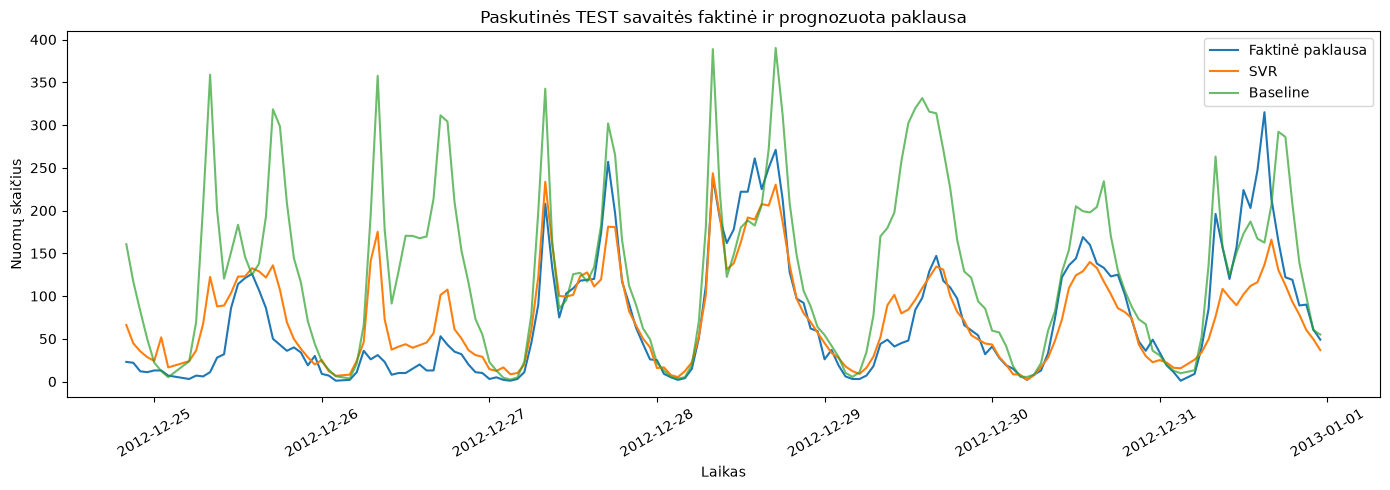

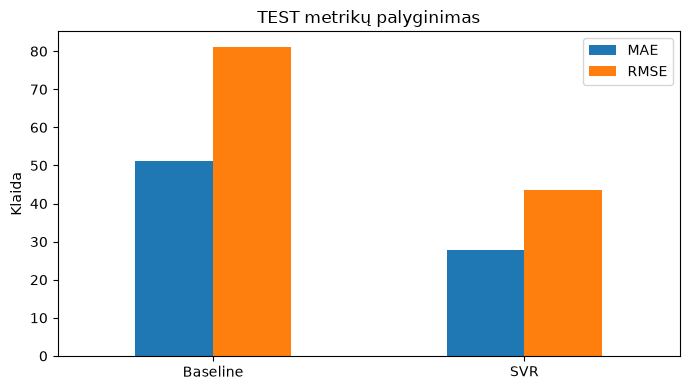

In [7]:
plot_df=test[["target_time","y"]].copy(); plot_df["prediction"]=test_pred; plot_df["baseline"]=test["baseline"].values
show=plot_df.tail(7*24)
plt.figure(figsize=(14,5)); plt.plot(show.target_time,show.y,label="Faktinė paklausa"); plt.plot(show.target_time,show.prediction,label=MODEL_NAME); plt.plot(show.target_time,show.baseline,label="Baseline",alpha=.7); plt.title("Paskutinės TEST savaitės faktinė ir prognozuota paklausa"); plt.xlabel("Laikas"); plt.ylabel("Nuomų skaičius"); plt.legend(); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4)); test_table[["MAE","RMSE"]].plot(kind="bar", ax=plt.gca()); plt.title("TEST metrikų palyginimas"); plt.ylabel("Klaida"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 7. Klaidų pavyzdžiai

In [8]:
err=test[["target_time","y"]].copy(); err["prediction"]=test_pred; err["error"]=err["prediction"]-err["y"]; err["abs_error"]=err["error"].abs()
print("10 didžiausių absoliučių klaidų:")
display(err.nlargest(10,"abs_error").round(2))

10 didžiausių absoliučių klaidų:


,target_time,y,prediction,error,abs_error
16717,2012-12-24 08:00:00,66.0,324.64,258.64,258.64
16216,2012-12-03 08:00:00,731.0,497.10,-233.90,233.90
16264,2012-12-05 08:00:00,759.0,525.98,-233.02,233.02
16634,2012-12-20 19:00:00,118.0,313.34,195.34,195.34
16239,2012-12-04 07:00:00,502.0,311.73,-190.27,190.27
16196,2012-12-02 12:00:00,520.0,334.89,-185.11,185.11
16560,2012-12-17 17:00:00,495.0,310.96,-184.04,184.04
16888,2012-12-31 15:00:00,315.0,136.58,-178.42,178.42
16226,2012-12-03 18:00:00,692.0,531.67,-160.33,160.33
16716,2012-12-24 07:00:00,30.0,187.98,157.98,157.98


## 8. Abliacija / požymių jautrumas

In [9]:
# Abliacija: pašaliname paklausos istorijos požymius ir palyginame tą patį modelį tame pačiame TEST.
no_history=[c for c in features if not c.startswith("cnt_")]
abl_model=model_factory(); abl_model.fit(dev[no_history],dev["y"]); abl_pred=np.maximum(0,abl_model.predict(test[no_history]))
abl=pd.DataFrame([metrics(test["y"],test_pred,q90_dev), metrics(test["y"],abl_pred,q90_dev)], index=["Pilnas modelis","Be paklausos istorijos"]); display(abl.round(3))

,MAE,RMSE,Peak_under_rate,N,N_peaks
Pilnas modelis,27.788,43.661,0.82,713,50
Be paklausos istorijos,55.988,99.966,1.00,713,50


## 9. Atsparumo bandymas – trūkstami duomenys

In [10]:
# Atsparumas trūkstamiems duomenims: 5 % TEST požymių reikšmių pakeičiame NaN.
rng=np.random.default_rng(SEED); Xmiss=test[features].copy(); mask=rng.random(Xmiss.shape)<0.05; Xmiss=Xmiss.mask(mask)
try:
    miss_pred=np.maximum(0,final_model.predict(Xmiss))
    robust=pd.DataFrame([metrics(test["y"],test_pred,q90_dev),metrics(test["y"],miss_pred,q90_dev)],index=["Originalus TEST","5% trūkstamų reikšmių"]); display(robust.round(3))
except Exception as e:
    print("Modelis tiesiogiai nepriima NaN; tai ir yra atsparumo testo rezultatas:", type(e).__name__, str(e)[:180])

,MAE,RMSE,Peak_under_rate,N,N_peaks
Originalus TEST,27.788,43.661,0.82,713,50
5% trūkstamų reikšmių,31.479,48.416,0.78,713,50


## 10. Ribos ir praktinis naudojimas
- UCI duomenys apima vieną sistemą ir istorinį laikotarpį, todėl rezultatų negalima automatiškai perkelti kitam miestui ar dabartinėms sąlygoms.
- Prognozuojamas visos sistemos nuomų skaičius, todėl vien šio modelio nepakanka konkrečių stočių perskirstymo maršrutams sudaryti.
- Naudojami tik prognozės momentu žinomi orai; realioje sistemoje ateities orams reikėtų orų prognozės šaltinio.
- Paklausos istorijos požymiai reikalauja patikimo ankstesnių valandų duomenų srauto.

**Veiksmas operatoriui:** didesnė prognozuojama kitos valandos paklausa gali būti signalas iš anksto didinti paruoštų dviračių rezervą / perskirstymo pajėgumą, tačiau konkretus perskirstymas reikalautų stočių lygio duomenų.